# 2b. Grid-Search Pipeline Validation

Compares the new-architecture grid-search CV (`analysis.grid_search`) against
legacy pickle results to verify that model rankings are preserved.

**Expected differences:**
- Absolute MSE numbers WILL differ (different `matrix_error` formula, different RNG)
- Model ranking per animal SHOULD be consistent

**Differences by design:**
| | Legacy | New |
|---|---|---|
| `matrix_error` | sum / n_columns | mean over all valid elements |
| RNG | `np.random.seed()` global | `np.random.default_rng()` instance |
| Psychometric σ₀ | 1.0 | 0.3 |
| Failed fit | returns None → NaN row | accepts finite params |
| Param format | `[σ, A, x, y]` list | named dict |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

from behav_utils.data.loading import load_experiment
from behav_utils.data.selection import select_sessions, register_preset, SessionFilter
from behav_utils.plotting.styles import COLOURS

from analysis.grid_search import grid_search_cv, COARSE_GRID, DEFAULT_GRID
from analysis.cv_utils import (
    load_cv_pickles, build_long_df, run_anova,
    format_params, sessions_to_old_df, compute_empirical_um,
)

## 1. Configuration

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ═══════════════════════════════════════════════════════════════════════════════

CONFIG_PATH = '../config.yaml'
LEGACY_RESULTS_DIR = '../results/grid_search/cv'     # directory with legacy cv_*_seed*.pkl

# Pick one animal and a few seeds for validation
TARGET_ANIMAL = 'SS01'
VALIDATION_SEEDS = [1, 2, 3]             # subset of seeds to compare

# Use coarse grid for speed (validation only — not final results)
USE_COARSE = True

# CV settings 
N_FOLDS = 2
BURN_IN = 1000

## 2. Load Data

In [4]:
experiment = load_experiment(CONFIG_PATH)
animal = experiment.get_animal(TARGET_ANIMAL)

expert_sessions = select_sessions(animal, 'expert_uniform')
print(f"{TARGET_ANIMAL}: {len(expert_sessions)} expert sessions")
for s in expert_sessions:
    acc = s.stats(['accuracy'])['accuracy']
    print(f"  idx={s.session_idx}, date={s.date}, "
          f"n={s.trials.valid_mask.sum()}, acc={acc:.2f}")

Loaded 12 animals, 433 total sessions
SS01: 11 expert sessions
  idx=23, date=2026-02-09, n=662, acc=0.71
  idx=28, date=2026-02-16, n=500, acc=0.76
  idx=29, date=2026-02-17, n=601, acc=0.71
  idx=33, date=2026-02-21, n=487, acc=0.70
  idx=34, date=2026-02-23, n=641, acc=0.74
  idx=37, date=2026-03-04, n=495, acc=0.73
  idx=38, date=2026-03-05, n=598, acc=0.71
  idx=39, date=2026-03-06, n=352, acc=0.74
  idx=41, date=2026-03-10, n=347, acc=0.74
  idx=42, date=2026-03-11, n=390, acc=nan
  idx=43, date=2026-03-13, n=301, acc=0.72


## 3. Load Legacy Results

In [5]:
# Load all legacy pickles for this animal
try:
    all_legacy = load_cv_pickles(LEGACY_RESULTS_DIR)
    legacy_results = all_legacy.get(TARGET_ANIMAL, [])
    print(f"Loaded {len(legacy_results)} legacy results for {TARGET_ANIMAL}")
    
    # Index by (model, seed) for easy lookup
    legacy_by_key = {}
    for r in legacy_results:
        legacy_by_key[(r['model'], r['seed'])] = r
    
    legacy_seeds = sorted(set(r['seed'] for r in legacy_results))
    print(f"Available seeds: {legacy_seeds[:10]}{'...' if len(legacy_seeds) > 10 else ''}")

except FileNotFoundError:
    print("No legacy results found — will run new pipeline only")
    legacy_results = []
    legacy_by_key = {}

No legacy results found — will run new pipeline only


## 4. Run New Pipeline

In [6]:
grids = COARSE_GRID if USE_COARSE else DEFAULT_GRID

new_results = {}  # {(model, seed): result_dict}

for seed in VALIDATION_SEEDS:
    for model_type in ['BE', 'SC']:
        key = (model_type, seed)
        print(f"Running {model_type} seed={seed}... ", end='', flush=True)
        
        t0 = time.time()
        result = grid_search_cv(
            sessions=expert_sessions,
            model_type=model_type,
            grid=grids[model_type],
            n_folds=N_FOLDS,
            seed=seed,
            burn_in=BURN_IN,
        )
        elapsed = time.time() - t0
        
        new_results[key] = result
        print(f"avg_error={result['avg_test_error']:.6f} ({elapsed:.1f}s)")

print(f"\nCompleted {len(new_results)} runs")

Running BE seed=1... avg_error=0.007344 (62.1s)
Running SC seed=1... avg_error=0.014342 (84.4s)
Running BE seed=2... avg_error=0.011350 (58.9s)
Running SC seed=2... avg_error=0.016711 (82.9s)
Running BE seed=3... avg_error=0.009502 (58.7s)
Running SC seed=3... avg_error=0.011348 (83.2s)

Completed 6 runs


## 5. Compare: Absolute Errors

These WILL differ due to RNG and `matrix_error` formula differences.
The question is whether the differences are reasonable (same order of magnitude)
and whether the model ranking is preserved.

In [7]:
rows = []
for seed in VALIDATION_SEEDS:
    for model_type in ['BE', 'SC']:
        key = (model_type, seed)
        
        new_err = new_results[key]['avg_test_error']
        
        legacy_err = np.nan
        if key in legacy_by_key:
            legacy_err = legacy_by_key[key]['avg_test_error']
        
        rows.append({
            'model': model_type,
            'seed': seed,
            'legacy_error': legacy_err,
            'new_error': new_err,
            'diff': new_err - legacy_err if not np.isnan(legacy_err) else np.nan,
            'ratio': new_err / legacy_err if (not np.isnan(legacy_err) and legacy_err > 0) else np.nan,
        })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False, float_format='{:.6f}'.format))

model  seed  legacy_error  new_error  diff  ratio
   BE     1           NaN   0.007344   NaN    NaN
   SC     1           NaN   0.014342   NaN    NaN
   BE     2           NaN   0.011350   NaN    NaN
   SC     2           NaN   0.016711   NaN    NaN
   BE     3           NaN   0.009502   NaN    NaN
   SC     3           NaN   0.011348   NaN    NaN


In [8]:
# Summary statistics
if comparison['legacy_error'].notna().any():
    print("Error ratios (new / legacy):")
    for model_type in ['BE', 'SC']:
        sub = comparison[(comparison['model'] == model_type) & comparison['ratio'].notna()]
        if len(sub) > 0:
            print(f"  {model_type}: mean={sub['ratio'].mean():.3f}, "
                  f"std={sub['ratio'].std():.3f}, "
                  f"range=[{sub['ratio'].min():.3f}, {sub['ratio'].max():.3f}]")
    print()
    print("Note: ratio < 1 means new pipeline gives lower errors (expected ")
    print("because behav_utils matrix_error divides by n_elements not n_columns).")
else:
    print("No legacy results to compare — showing new pipeline results only.")
    print(comparison[['model', 'seed', 'new_error']].to_string(index=False))

No legacy results to compare — showing new pipeline results only.
model  seed  new_error
   BE     1   0.007344
   SC     1   0.014342
   BE     2   0.011350
   SC     2   0.016711
   BE     3   0.009502
   SC     3   0.011348


## 6. Compare: Model Rankings

The critical test: does the new pipeline agree with the legacy pipeline on
which model wins (lower test error) at each seed?

In [9]:
ranking_rows = []
for seed in VALIDATION_SEEDS:
    be_new = new_results[('BE', seed)]['avg_test_error']
    sc_new = new_results[('SC', seed)]['avg_test_error']
    new_winner = 'BE' if be_new < sc_new else 'SC'
    
    legacy_winner = '?'
    if ('BE', seed) in legacy_by_key and ('SC', seed) in legacy_by_key:
        be_leg = legacy_by_key[('BE', seed)]['avg_test_error']
        sc_leg = legacy_by_key[('SC', seed)]['avg_test_error']
        if not (np.isnan(be_leg) or np.isnan(sc_leg)):
            legacy_winner = 'BE' if be_leg < sc_leg else 'SC'
    
    agree = (new_winner == legacy_winner) if legacy_winner != '?' else None
    
    ranking_rows.append({
        'seed': seed,
        'new_winner': new_winner,
        'legacy_winner': legacy_winner,
        'agree': agree,
        'new_BE': be_new,
        'new_SC': sc_new,
    })

ranking_df = pd.DataFrame(ranking_rows)
print(ranking_df.to_string(index=False))

if ranking_df['agree'].notna().any():
    n_agree = ranking_df['agree'].sum()
    n_total = ranking_df['agree'].notna().sum()
    print(f"\nAgreement: {n_agree}/{n_total} seeds ({n_agree/n_total:.0%})")
    if n_agree < n_total:
        print("Disagreements may be due to RNG differences on borderline cases.")
        print("Check whether disagreeing seeds have small BE-SC error gaps.")

 seed new_winner legacy_winner agree   new_BE   new_SC
    1         BE             ?  None 0.007344 0.014342
    2         BE             ?  None 0.011350 0.016711
    3         BE             ?  None 0.009502 0.011348


## 7. Compare: Best-Fit Parameters

Are the best-fit parameters in similar regions of parameter space?

In [10]:
for seed in VALIDATION_SEEDS:
    print(f"\n── Seed {seed} ──")
    for model_type in ['BE', 'SC']:
        new_params = new_results[(model_type, seed)]['best_params_single']
        new_named = format_params(model_type, new_params)
        
        print(f"  {model_type} (new):    ", end='')
        print(', '.join(f'{k}={v:.3f}' for k, v in new_named.items()))
        
        key = (model_type, seed)
        if key in legacy_by_key and legacy_by_key[key]['best_params'] is not None:
            legacy_params = legacy_by_key[key]['best_params']
            # Take fold 0 from legacy (list format)
            if isinstance(legacy_params, list) and len(legacy_params) > 0:
                leg_named = format_params(model_type, legacy_params[0])
                print(f"  {model_type} (legacy): ", end='')
                print(', '.join(f'{k}={v:.3f}' for k, v in leg_named.items()))
        else:
            print(f"  {model_type} (legacy): not available")


── Seed 1 ──
  BE (new):    A_repulsion=0.000, eta_learning=0.214, eta_relax=0.400, sigma_noise=0.133
  BE (legacy): not available
  SC (new):    A_repulsion=0.500, gamma=0.743, sigma_update=1.000, sigma_noise=0.300
  SC (legacy): not available

── Seed 2 ──
  BE (new):    A_repulsion=0.250, eta_learning=0.100, eta_relax=0.283, sigma_noise=0.217
  BE (legacy): not available
  SC (new):    A_repulsion=0.000, gamma=0.614, sigma_update=0.700, sigma_noise=0.217
  SC (legacy): not available

── Seed 3 ──
  BE (new):    A_repulsion=0.000, eta_learning=0.100, eta_relax=0.167, sigma_noise=0.050
  BE (legacy): not available
  SC (new):    A_repulsion=0.500, gamma=0.614, sigma_update=1.000, sigma_noise=0.133
  SC (legacy): not available


## 8. Visual: New Pipeline Error Distributions

Quick violin plot from the seeds we ran.

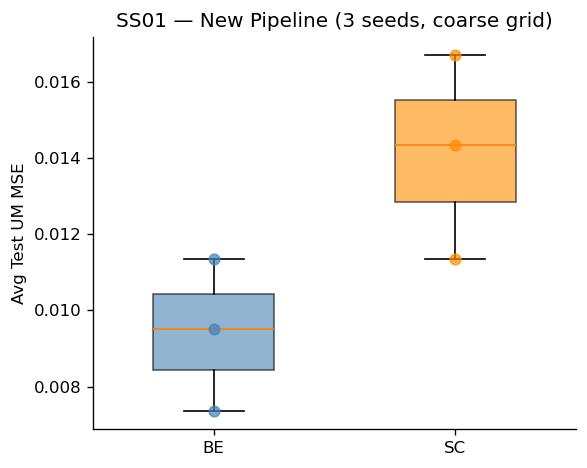

In [11]:
be_errors = [new_results[('BE', s)]['avg_test_error'] for s in VALIDATION_SEEDS]
sc_errors = [new_results[('SC', s)]['avg_test_error'] for s in VALIDATION_SEEDS]

fig, ax = plt.subplots(figsize=(5, 4))
positions = [0, 1]
bp = ax.boxplot([be_errors, sc_errors], positions=positions, widths=0.5,
                patch_artist=True, showfliers=True)
bp['boxes'][0].set_facecolor(COLOURS['BE'])
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor(COLOURS['SC'])
bp['boxes'][1].set_alpha(0.6)

# Overlay individual seeds
ax.scatter(np.zeros(len(be_errors)), be_errors,
           c=COLOURS['BE'], alpha=0.7, s=40, zorder=3)
ax.scatter(np.ones(len(sc_errors)), sc_errors,
           c=COLOURS['SC'], alpha=0.7, s=40, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(['BE', 'SC'])
ax.set_ylabel('Avg Test UM MSE')
ax.set_title(f'{TARGET_ANIMAL} — New Pipeline ({len(VALIDATION_SEEDS)} seeds, '
             f'{"coarse" if USE_COARSE else "full"} grid)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Conclusion

**If agreement is high (>80% of seeds):** The new pipeline is validated.
Remaining disagreements are expected on borderline seeds where BE and SC
have similar errors and RNG differences tip the balance.

**If agreement is low (<60%):** Something is wrong. Check:
1. Was the legacy run using `fit_with='update'`? (Check `submit_cv.sh`)
2. Are the same expert sessions being selected? (Compare session counts)
3. Is the fold splitting producing the same block groupings?

**Next step:** Once validated, run the full 64-seed analysis with the new
pipeline via `cluster/run_cv_single.py` and use `notebooks/3a_cv_grid_search.ipynb`
for the final analysis.